- Cleaned dataset summary
- Class distribution
- Sample images
- Train / validation / test split
- Data augmentation examples
- PyTorch DataLoader check
- Baseline CNN training curves
- Baseline evaluation results and confusion matrix

## 1. Setup
This cell finds the project root and loads paths from `src/config.py`.

In [25]:
from pathlib import Path
import sys

# Find project root
current_path = Path.cwd().resolve()
if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Src folder:", SRC_DIR)
print("Src exists:", SRC_DIR.exists())

from config import (
    DATA_DIR,
    PROCESSED_DIR,
    SPLIT_CSV,
    OUTPUT_DIR,
    FIGURE_DIR,
    RESULT_DIR,
    MODEL_DIR,
    CLASS_NAMES,
    LABEL_MAP,
    IMAGE_SIZE,
    BATCH_SIZE,
    DEVICE,
)

print("Dataset folder:", DATA_DIR)
print("Output folder:", OUTPUT_DIR)

Project root: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1
Src folder: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\src
Src exists: True
Dataset folder: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\data\raw\Digital Knee X-ray Images\MedicalExpert-I
Output folder: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs


## 2. Import libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as IPyImage, Markdown

plt.rcParams["figure.figsize"] = (8, 5)

## 3. Dataset summary after cleaning

This section reads `outputs/results/dataset_summary.csv`, which should be generated by:

```bash
python src/check_dataset.py
```

Current cleaned dataset should contain the single-knee images only.

In [27]:
dataset_summary_path = RESULT_DIR / "dataset_summary.csv"

if not dataset_summary_path.exists():
    display(Markdown(
        f"`dataset_summary.csv` not found at `{dataset_summary_path}`. "
        "Run `python src/check_dataset.py` first."
    ))
else:
    df = pd.read_csv(dataset_summary_path)

    display(Markdown("### Dataset Summary"))
    print("Total images:", len(df))

    display(Markdown("### Class Distribution"))
    class_counts = (
        df.groupby(["label", "class_name"])
        .size()
        .reset_index(name="count")
    )
    display(class_counts)

    display(Markdown("### Image Modes"))
    display(df["mode"].value_counts().reset_index().rename(
        columns={"index": "mode", "mode": "count"}
    ))

    display(Markdown("### Image Size Summary"))
    display(df[["width", "height"]].describe())

### Dataset Summary

Total images: 1464


### Class Distribution

,label,class_name,count
0,0,Normal,452
1,1,Doubtful,440
2,2,Mild,191
3,3,Moderate,175
4,4,Severe,206


### Image Modes

,count,count
0,RGB,1403
1,I;16,61


### Image Size Summary

,width,height
count,1464.0,1464.0
mean,300.0,162.0
std,0.0,0.0
min,300.0,162.0
25%,300.0,162.0
50%,300.0,162.0
75%,300.0,162.0
max,300.0,162.0


## 4. Class distribution figure

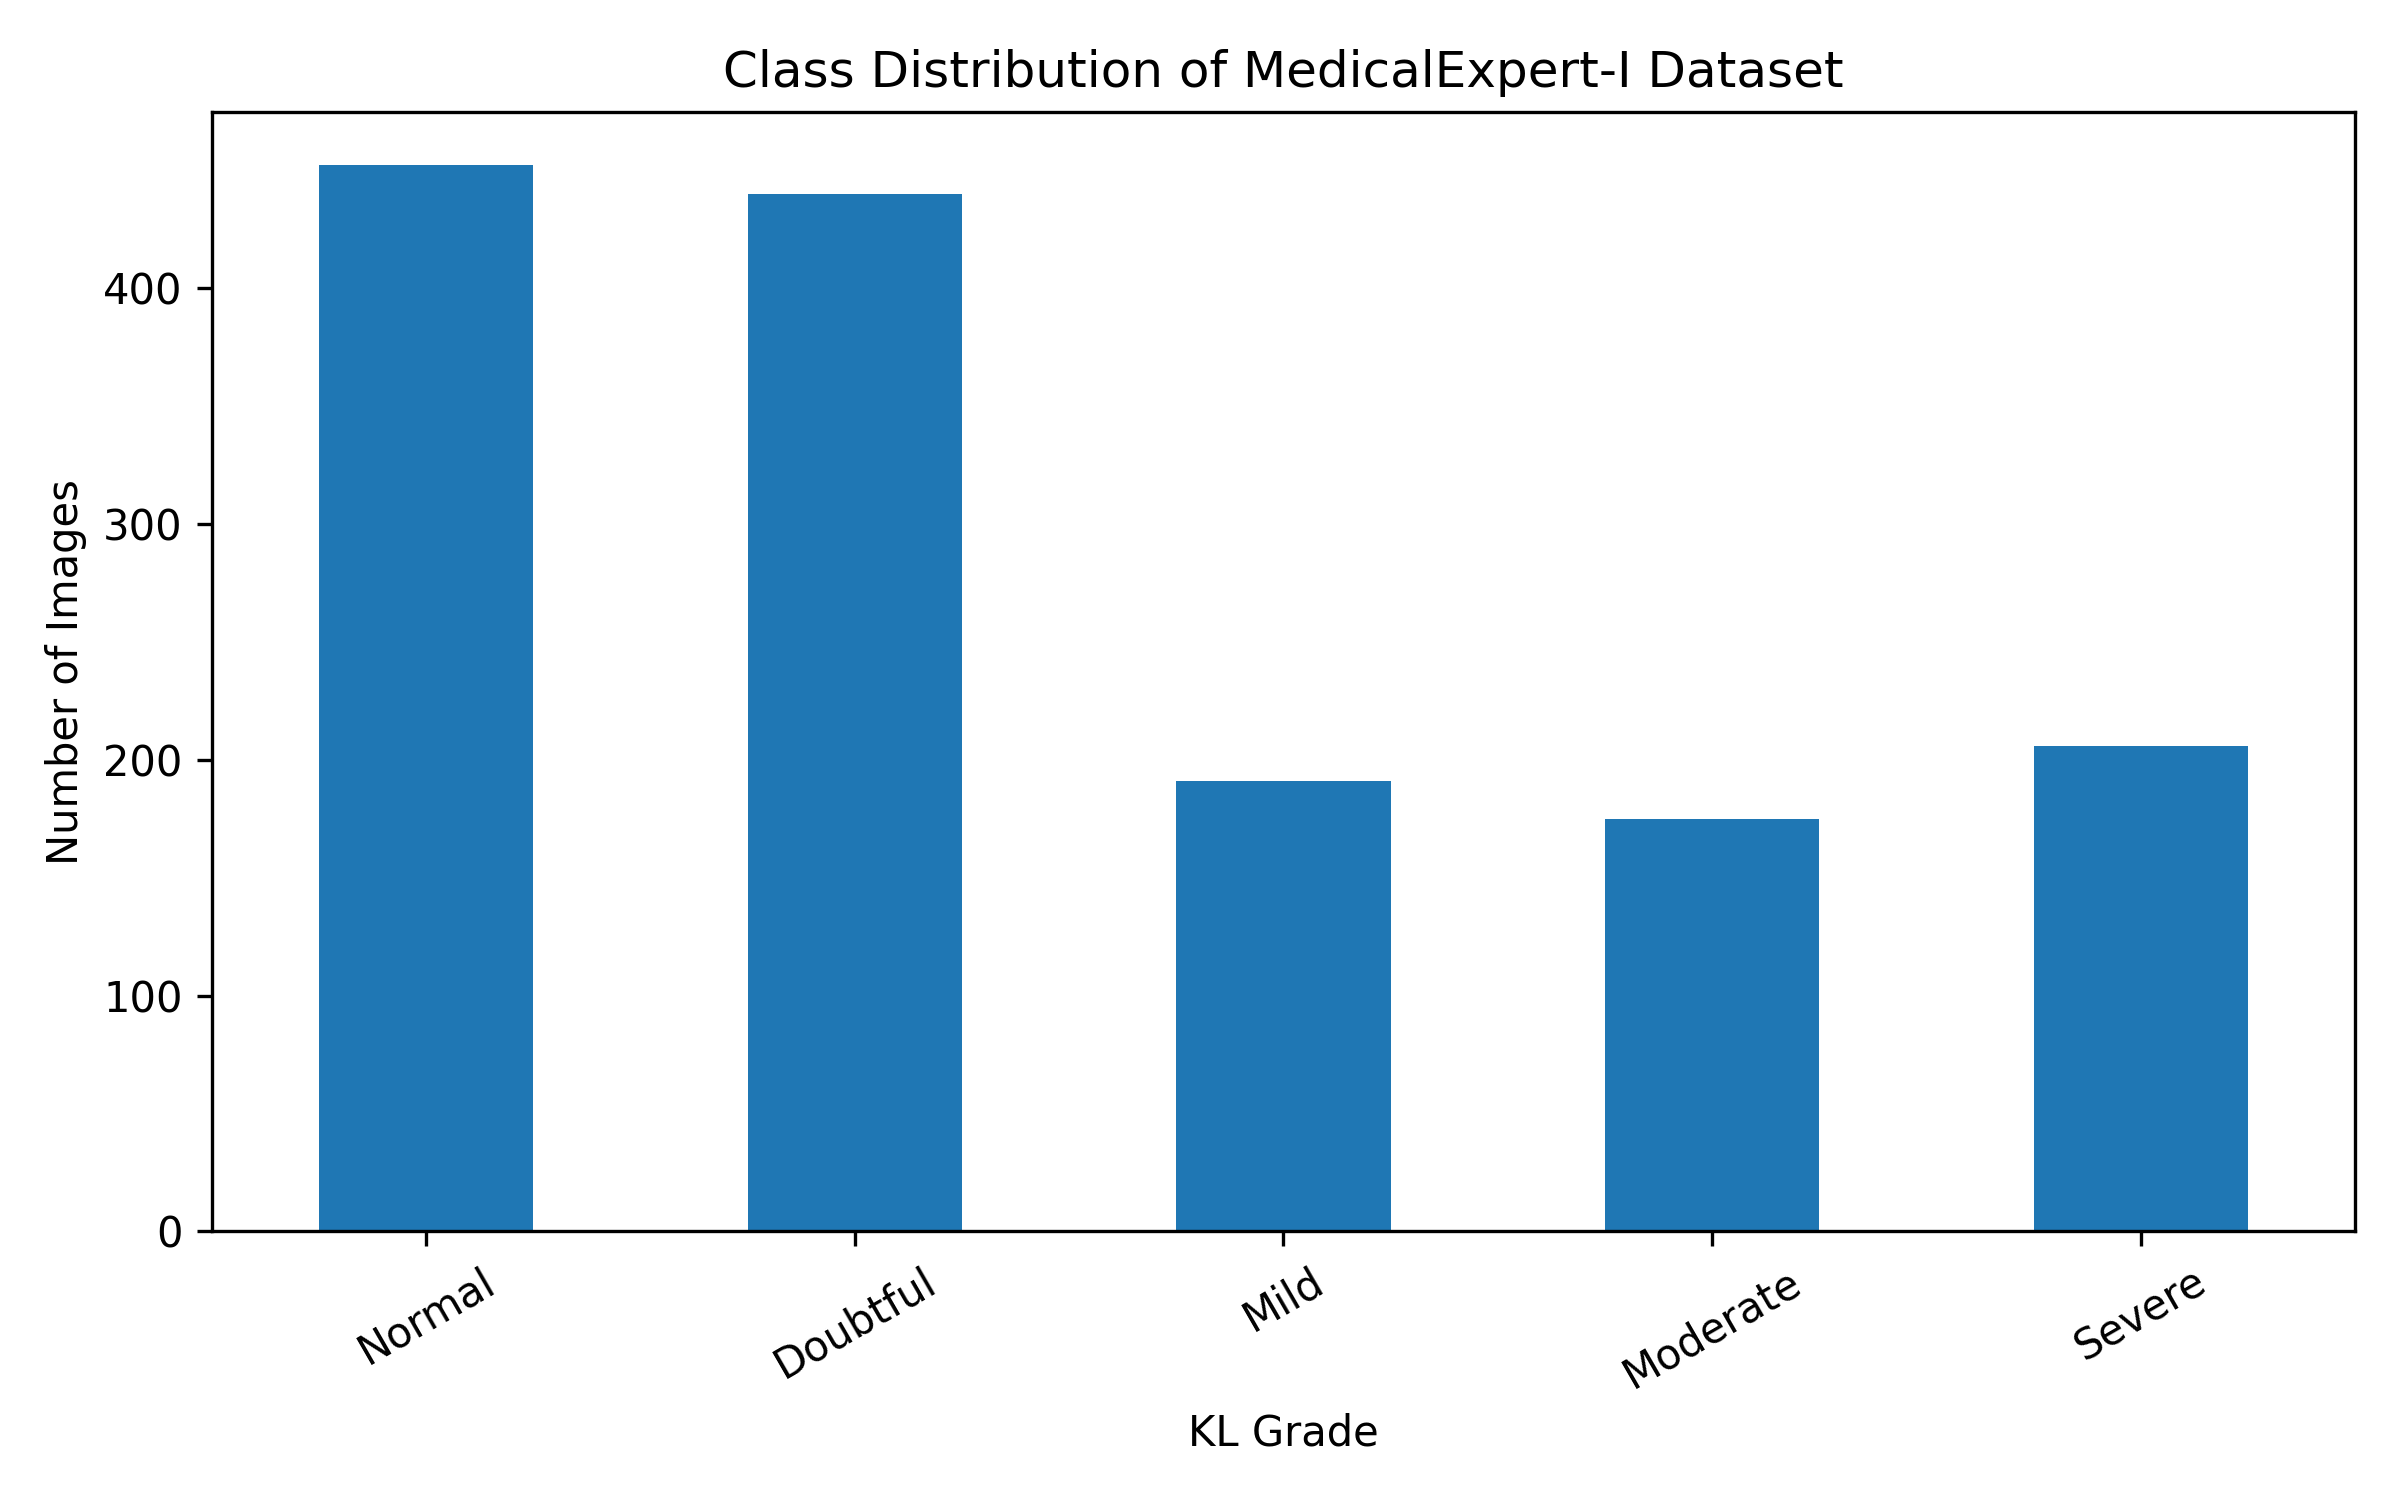

In [16]:
class_distribution_path = FIGURE_DIR / "class_distribution.png"

if class_distribution_path.exists():
    display(IPyImage(filename=str(class_distribution_path)))
else:
    display(Markdown(
        f" Class distribution figure not found: `{class_distribution_path}`"
    ))

## 5. Sample images from each KL grade

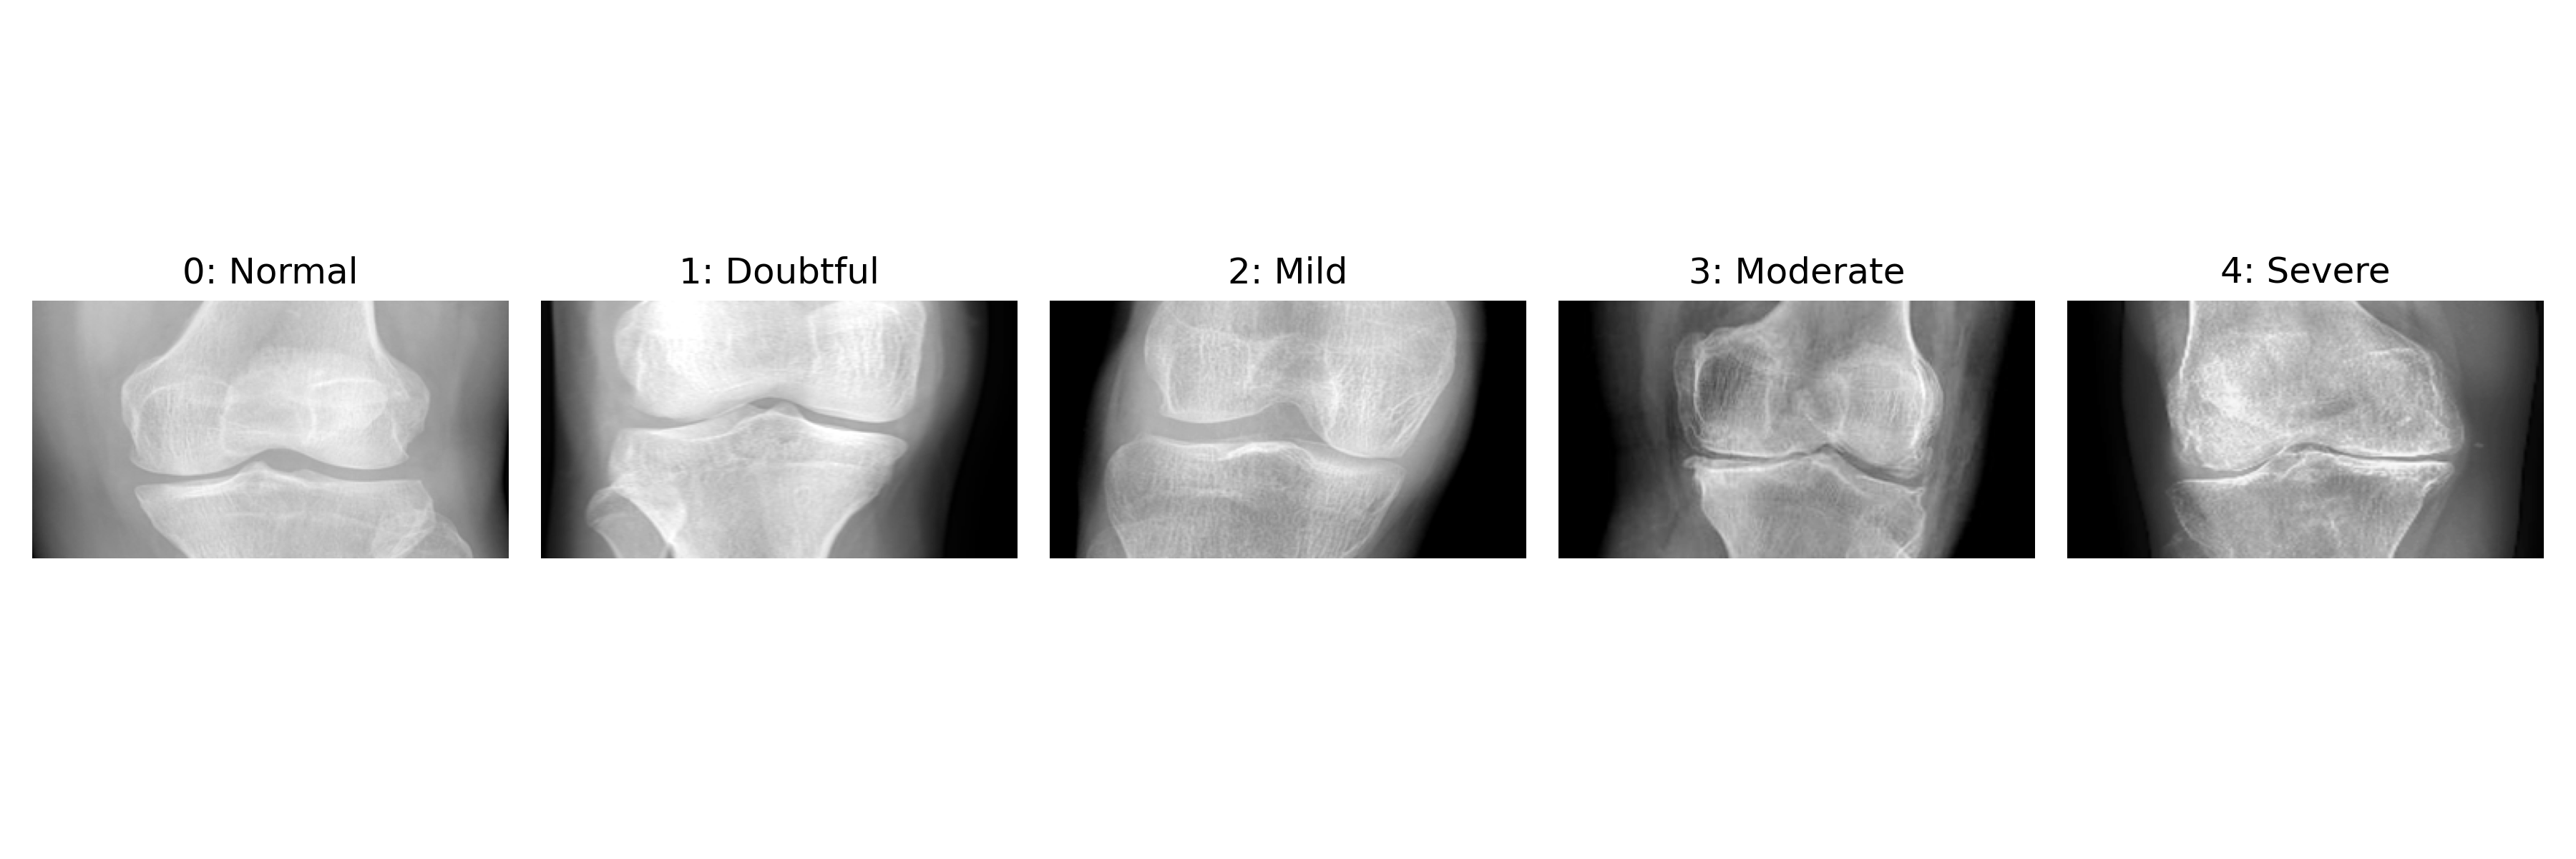

In [17]:
sample_images_path = FIGURE_DIR / "sample_images.png"

if sample_images_path.exists():
    display(IPyImage(filename=str(sample_images_path)))
else:
    display(Markdown(
        f"Sample image figure not found: `{sample_images_path}`"
    ))

## 6. Train / validation / test split

This section reads `data/processed/splits.csv`, which should be generated by:

```bash
python src/create_split.py
```

In [18]:
if not SPLIT_CSV.exists():
    display(Markdown(
        f" `splits.csv` not found at `{SPLIT_CSV}`. "
        "Run `python src/create_split.py` first."
    ))
else:
    split_df = pd.read_csv(SPLIT_CSV)

    display(Markdown("### Split Counts"))
    split_counts = split_df["split"].value_counts().reset_index()
    split_counts.columns = ["split", "count"]
    display(split_counts)

    display(Markdown("### Split Distribution by Class"))
    split_dist = (
        split_df.groupby(["split", "label", "class_name"])
        .size()
        .reset_index(name="count")
        .sort_values(["split", "label"])
    )
    display(split_dist)

    display(Markdown("### Pivot Table"))
    split_pivot = split_dist.pivot_table(
        index=["label", "class_name"],
        columns="split",
        values="count",
        fill_value=0
    )
    display(split_pivot)

### Split Counts

,split,count
0,train,1024
1,test,294
2,val,146


### Split Distribution by Class

,split,label,class_name,count
0,test,0,Normal,91
1,test,1,Doubtful,88
2,test,2,Mild,38
3,test,3,Moderate,35
4,test,4,Severe,42
5,train,0,Normal,316
6,train,1,Doubtful,308
7,train,2,Mild,134
8,train,3,Moderate,122
9,train,4,Severe,144


### Pivot Table

,split,test,train,val
label,class_name,,,
0,Normal,91.0,316.0,45.0
1,Doubtful,88.0,308.0,44.0
2,Mild,38.0,134.0,19.0
3,Moderate,35.0,122.0,18.0
4,Severe,42.0,144.0,20.0


## 7. Data augmentation examples

This image should be generated by:

```bash
python src/visualize_augmentation.py
```

It shows original training images and augmented versions.

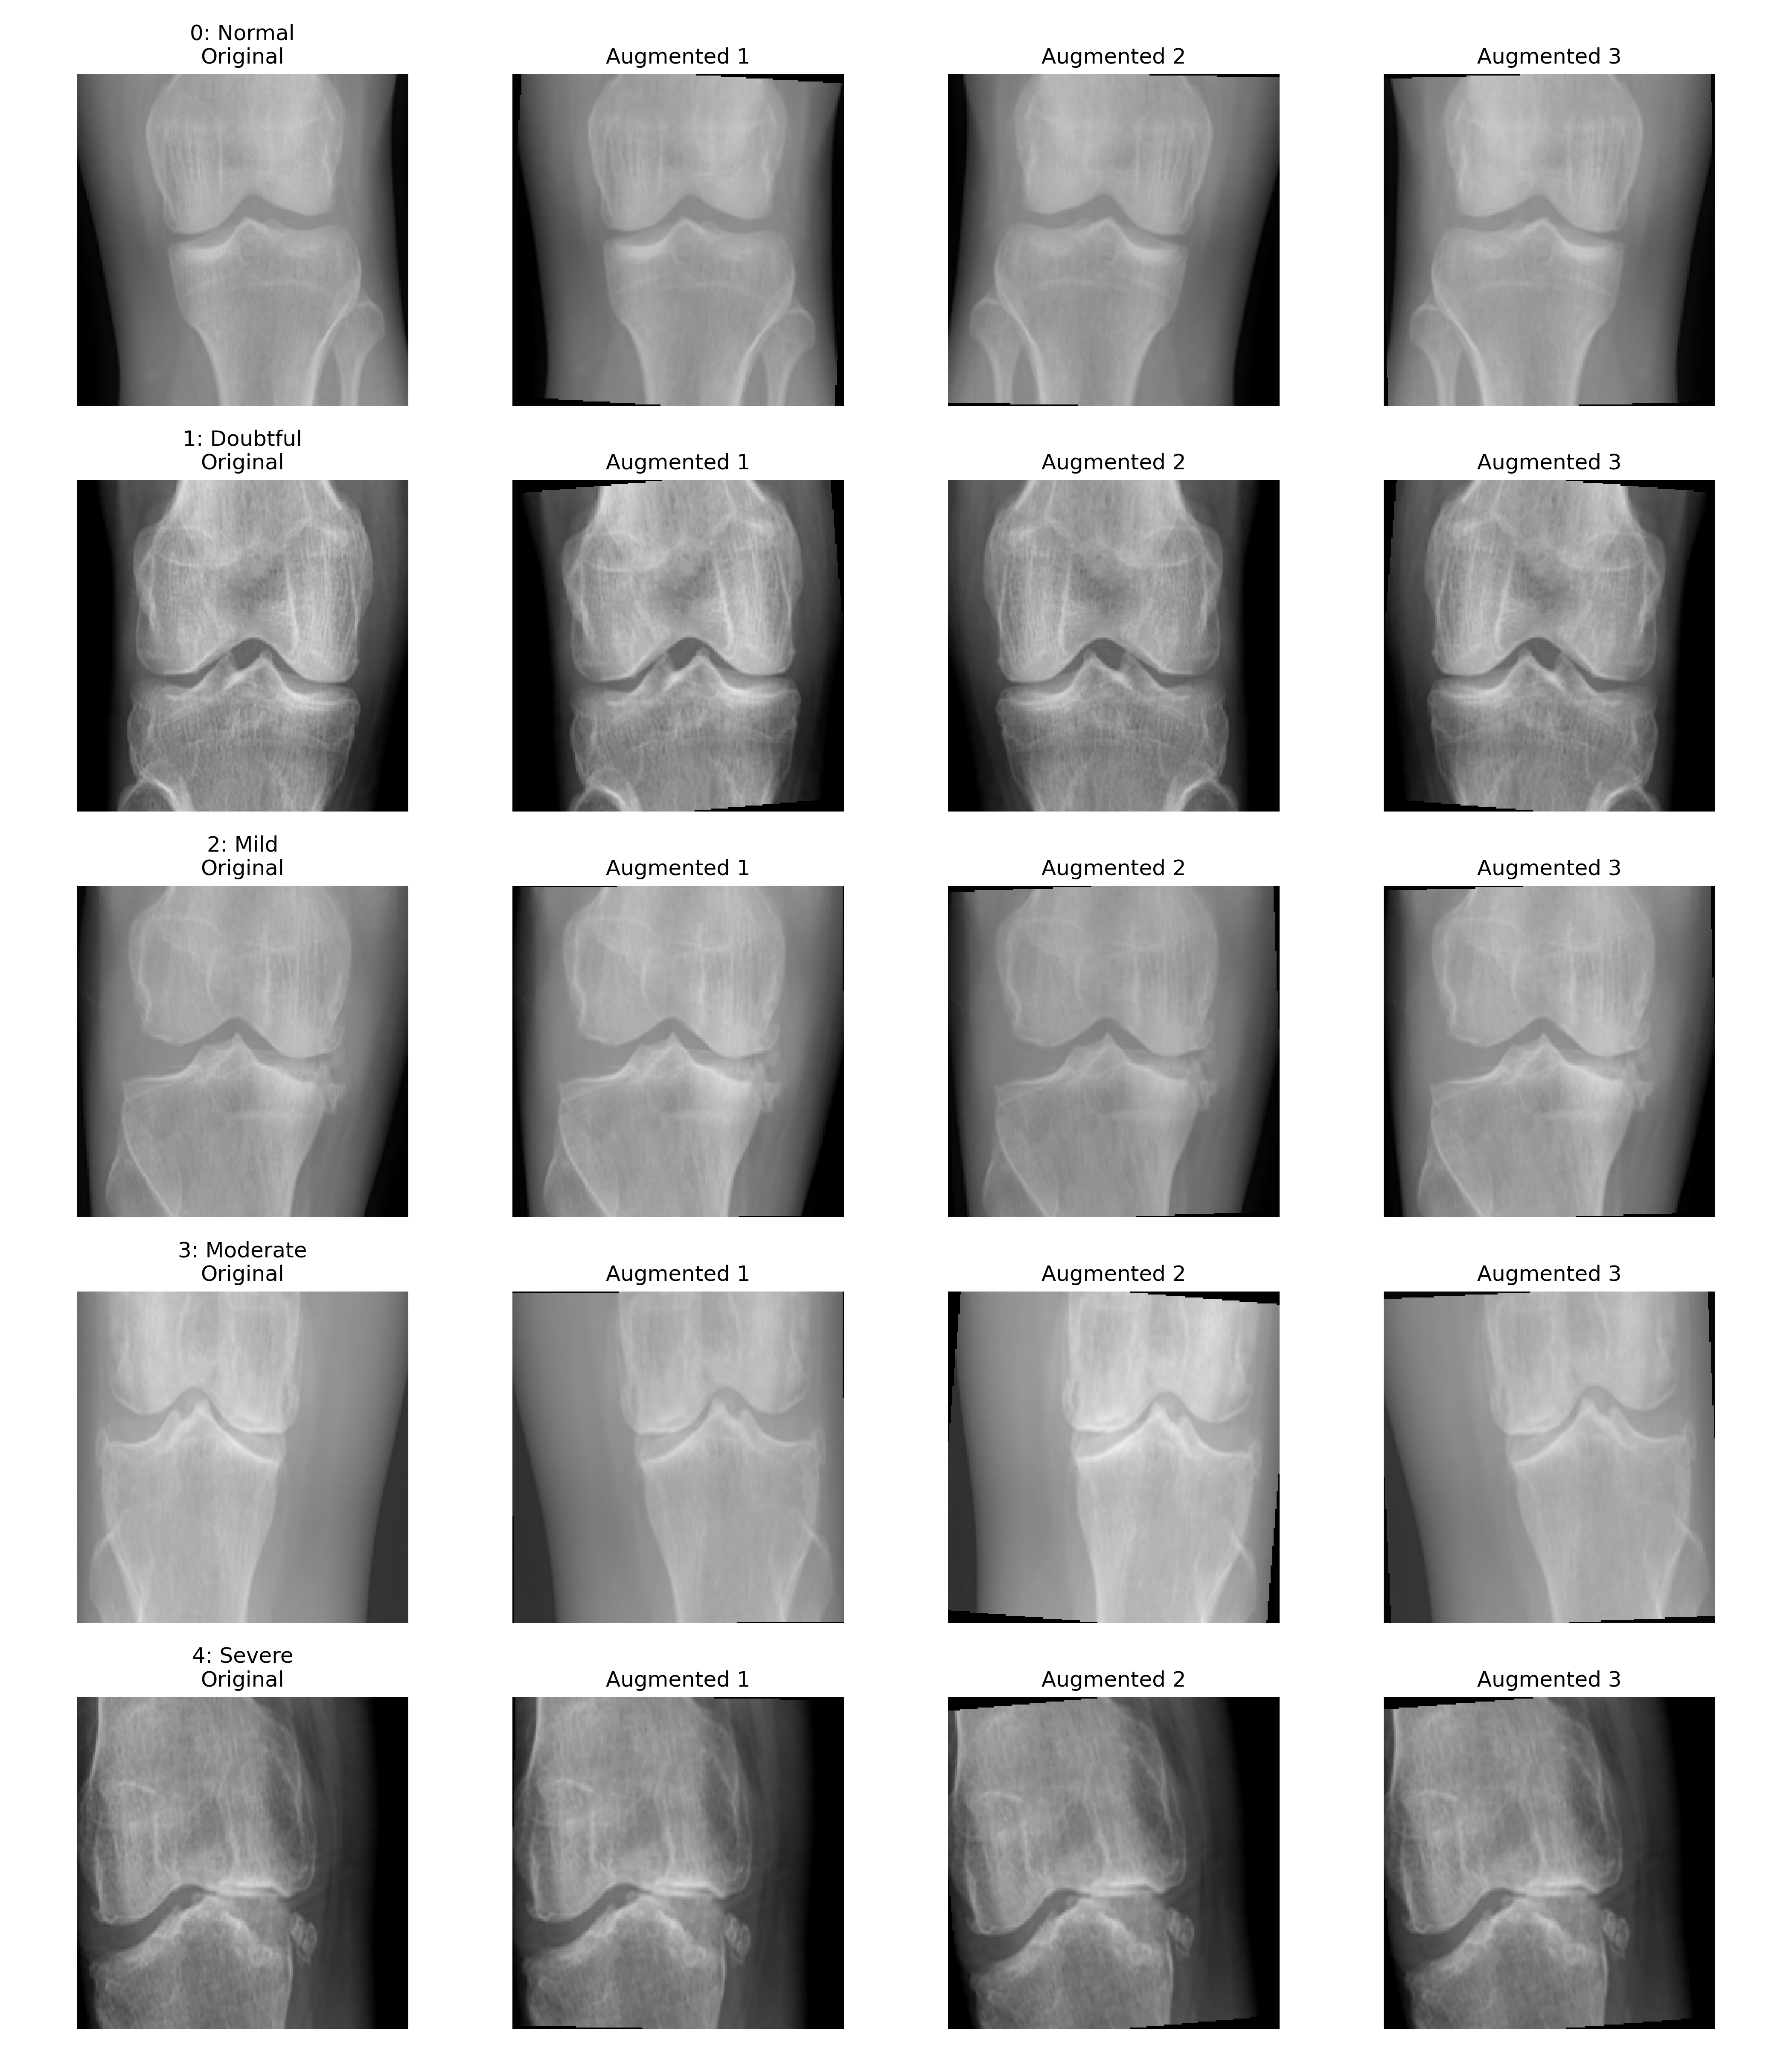

In [19]:
augmentation_path = FIGURE_DIR / "augmentation_examples.png"

if augmentation_path.exists():
    display(IPyImage(filename=str(augmentation_path)))
else:
    display(Markdown(
        f" Augmentation example figure not found: `{augmentation_path}`. "
        "Run `python src/visualize_augmentation.py` first."
    ))

## 8. PyTorch DataLoader check

This confirms that the model receives image batches with shape:

```text
[batch_size, 3, 224, 224]
```

In [20]:
try:
    from dataset import get_dataloaders

    train_loader, val_loader, test_loader = get_dataloaders()

    print("Train batches:", len(train_loader))
    print("Validation batches:", len(val_loader))
    print("Test batches:", len(test_loader))

    images, labels = next(iter(train_loader))

    print("\nOne training batch:")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels:", labels)
except Exception as e:
    display(Markdown(f" DataLoader check failed: `{e}`"))

Train batches: 64
Validation batches: 10
Test batches: 19

One training batch:
Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([2, 1, 0, 0, 2, 4, 1, 2, 4, 3, 0, 4, 0, 0, 2, 2])


## 9. Baseline CNN training summary

This section reads files generated by:

```bash
python src/train_baseline.py
```

### Baseline Training Summary

,model,loss,optimizer,learning_rate,best_val_loss,best_val_acc,epochs_trained,training_time_seconds
0,BaselineCNN,CrossEntropyLoss,Adam,0.001,1.206979,0.534247,20,886.316768


### Baseline Training History

,epoch,train_loss,train_acc,val_loss,val_acc
15,16,1.298858,0.427734,1.551803,0.287671
16,17,1.295381,0.432617,1.383767,0.424658
17,18,1.263824,0.437500,1.206979,0.534247
18,19,1.284857,0.444336,1.262793,0.452055
19,20,1.295174,0.429688,1.500404,0.342466


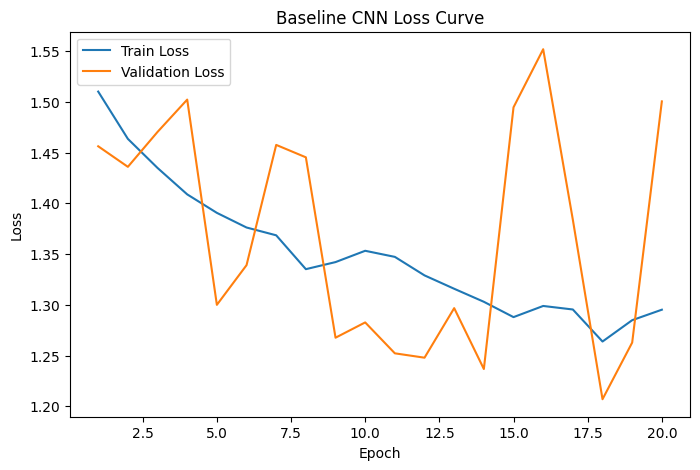

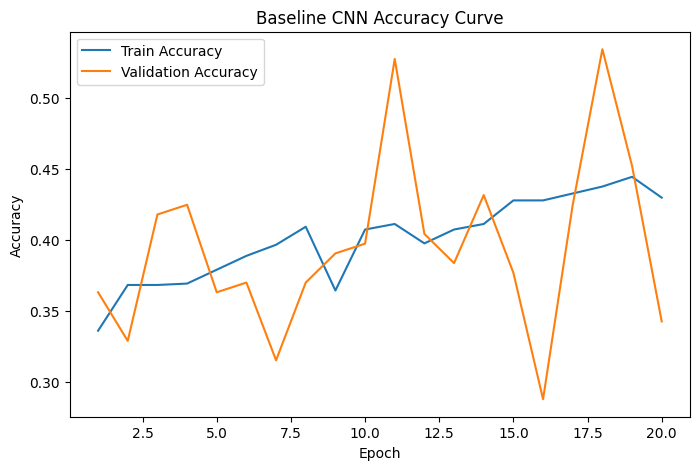

In [21]:
training_summary_path = RESULT_DIR / "baseline_training_summary.csv"
training_history_path = RESULT_DIR / "baseline_training_history.csv"

if training_summary_path.exists():
    display(Markdown("### Baseline Training Summary"))
    training_summary = pd.read_csv(training_summary_path)
    display(training_summary)
else:
    display(Markdown(
        f"Baseline training summary not found: `{training_summary_path}`. "
        "Run `python src/train_baseline.py` first."
    ))

if training_history_path.exists():
    display(Markdown("### Baseline Training History"))
    history_df = pd.read_csv(training_history_path)
    display(history_df.tail())

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Baseline CNN Loss Curve")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Baseline CNN Accuracy Curve")
    plt.legend()
    plt.show()
else:
    display(Markdown(
        f"Baseline training history not found: `{training_history_path}`. "
        "Run `python src/train_baseline.py` first."
    ))

## 10. Saved baseline training curve images

### Loss Curve

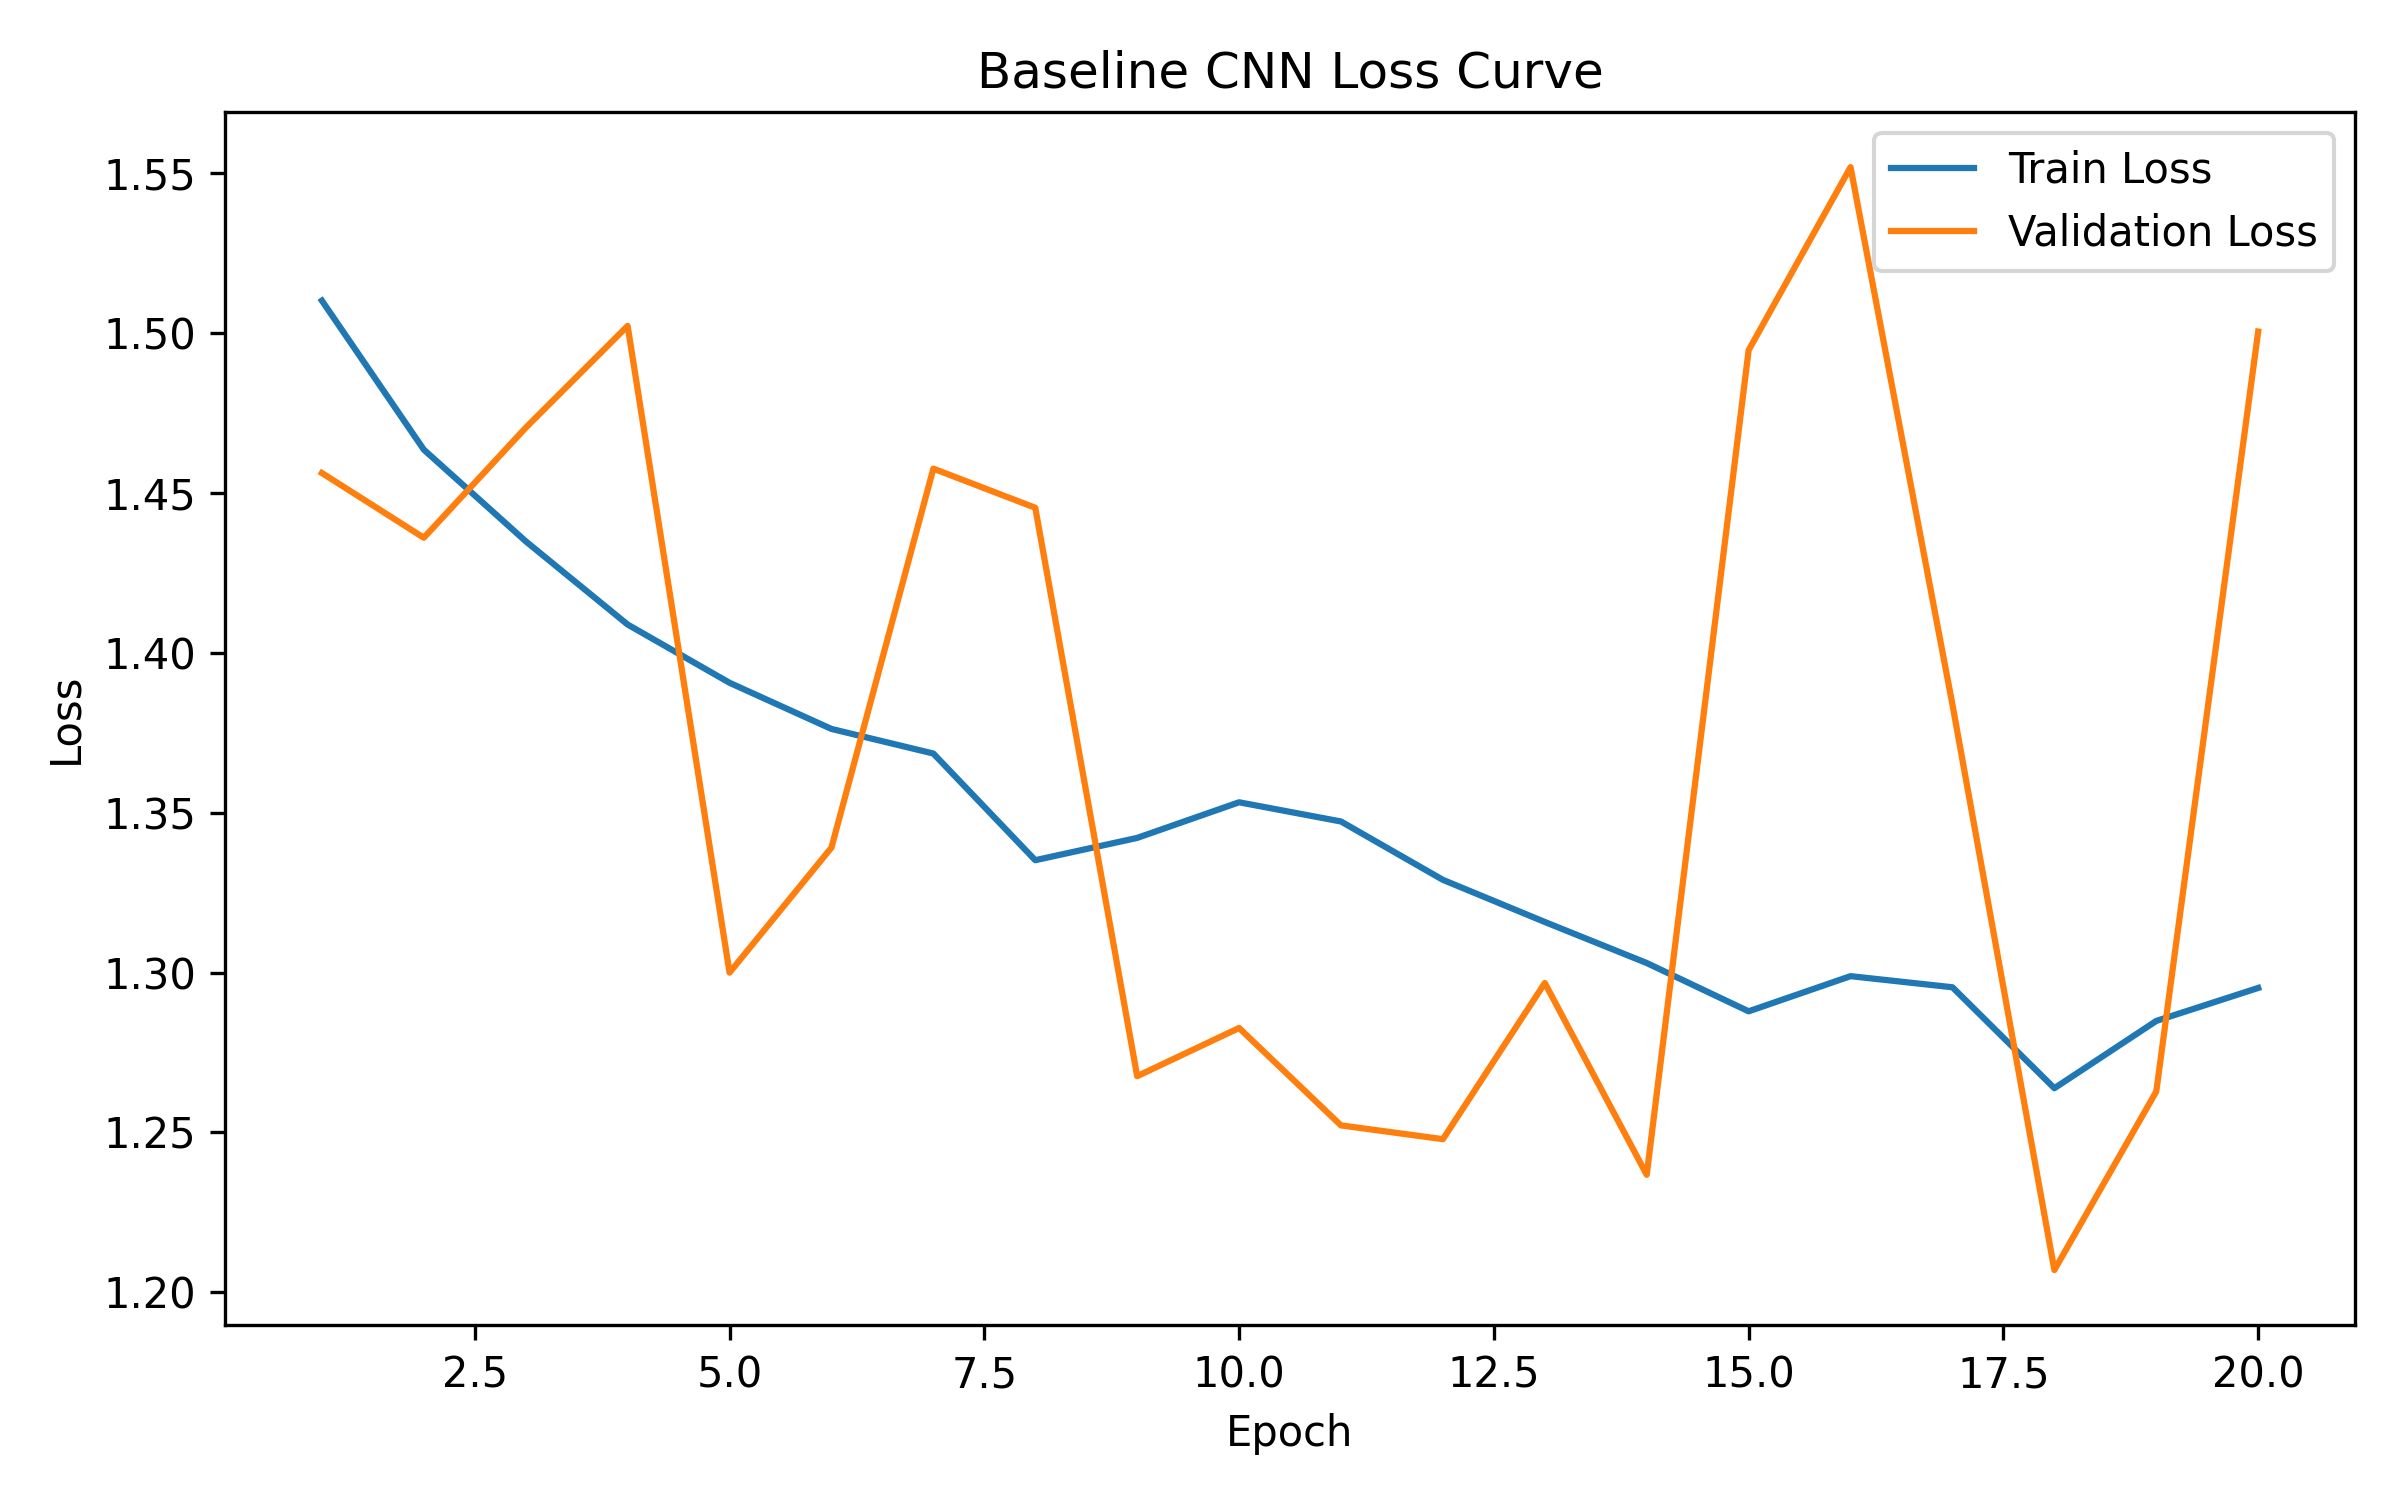

### Accuracy Curve

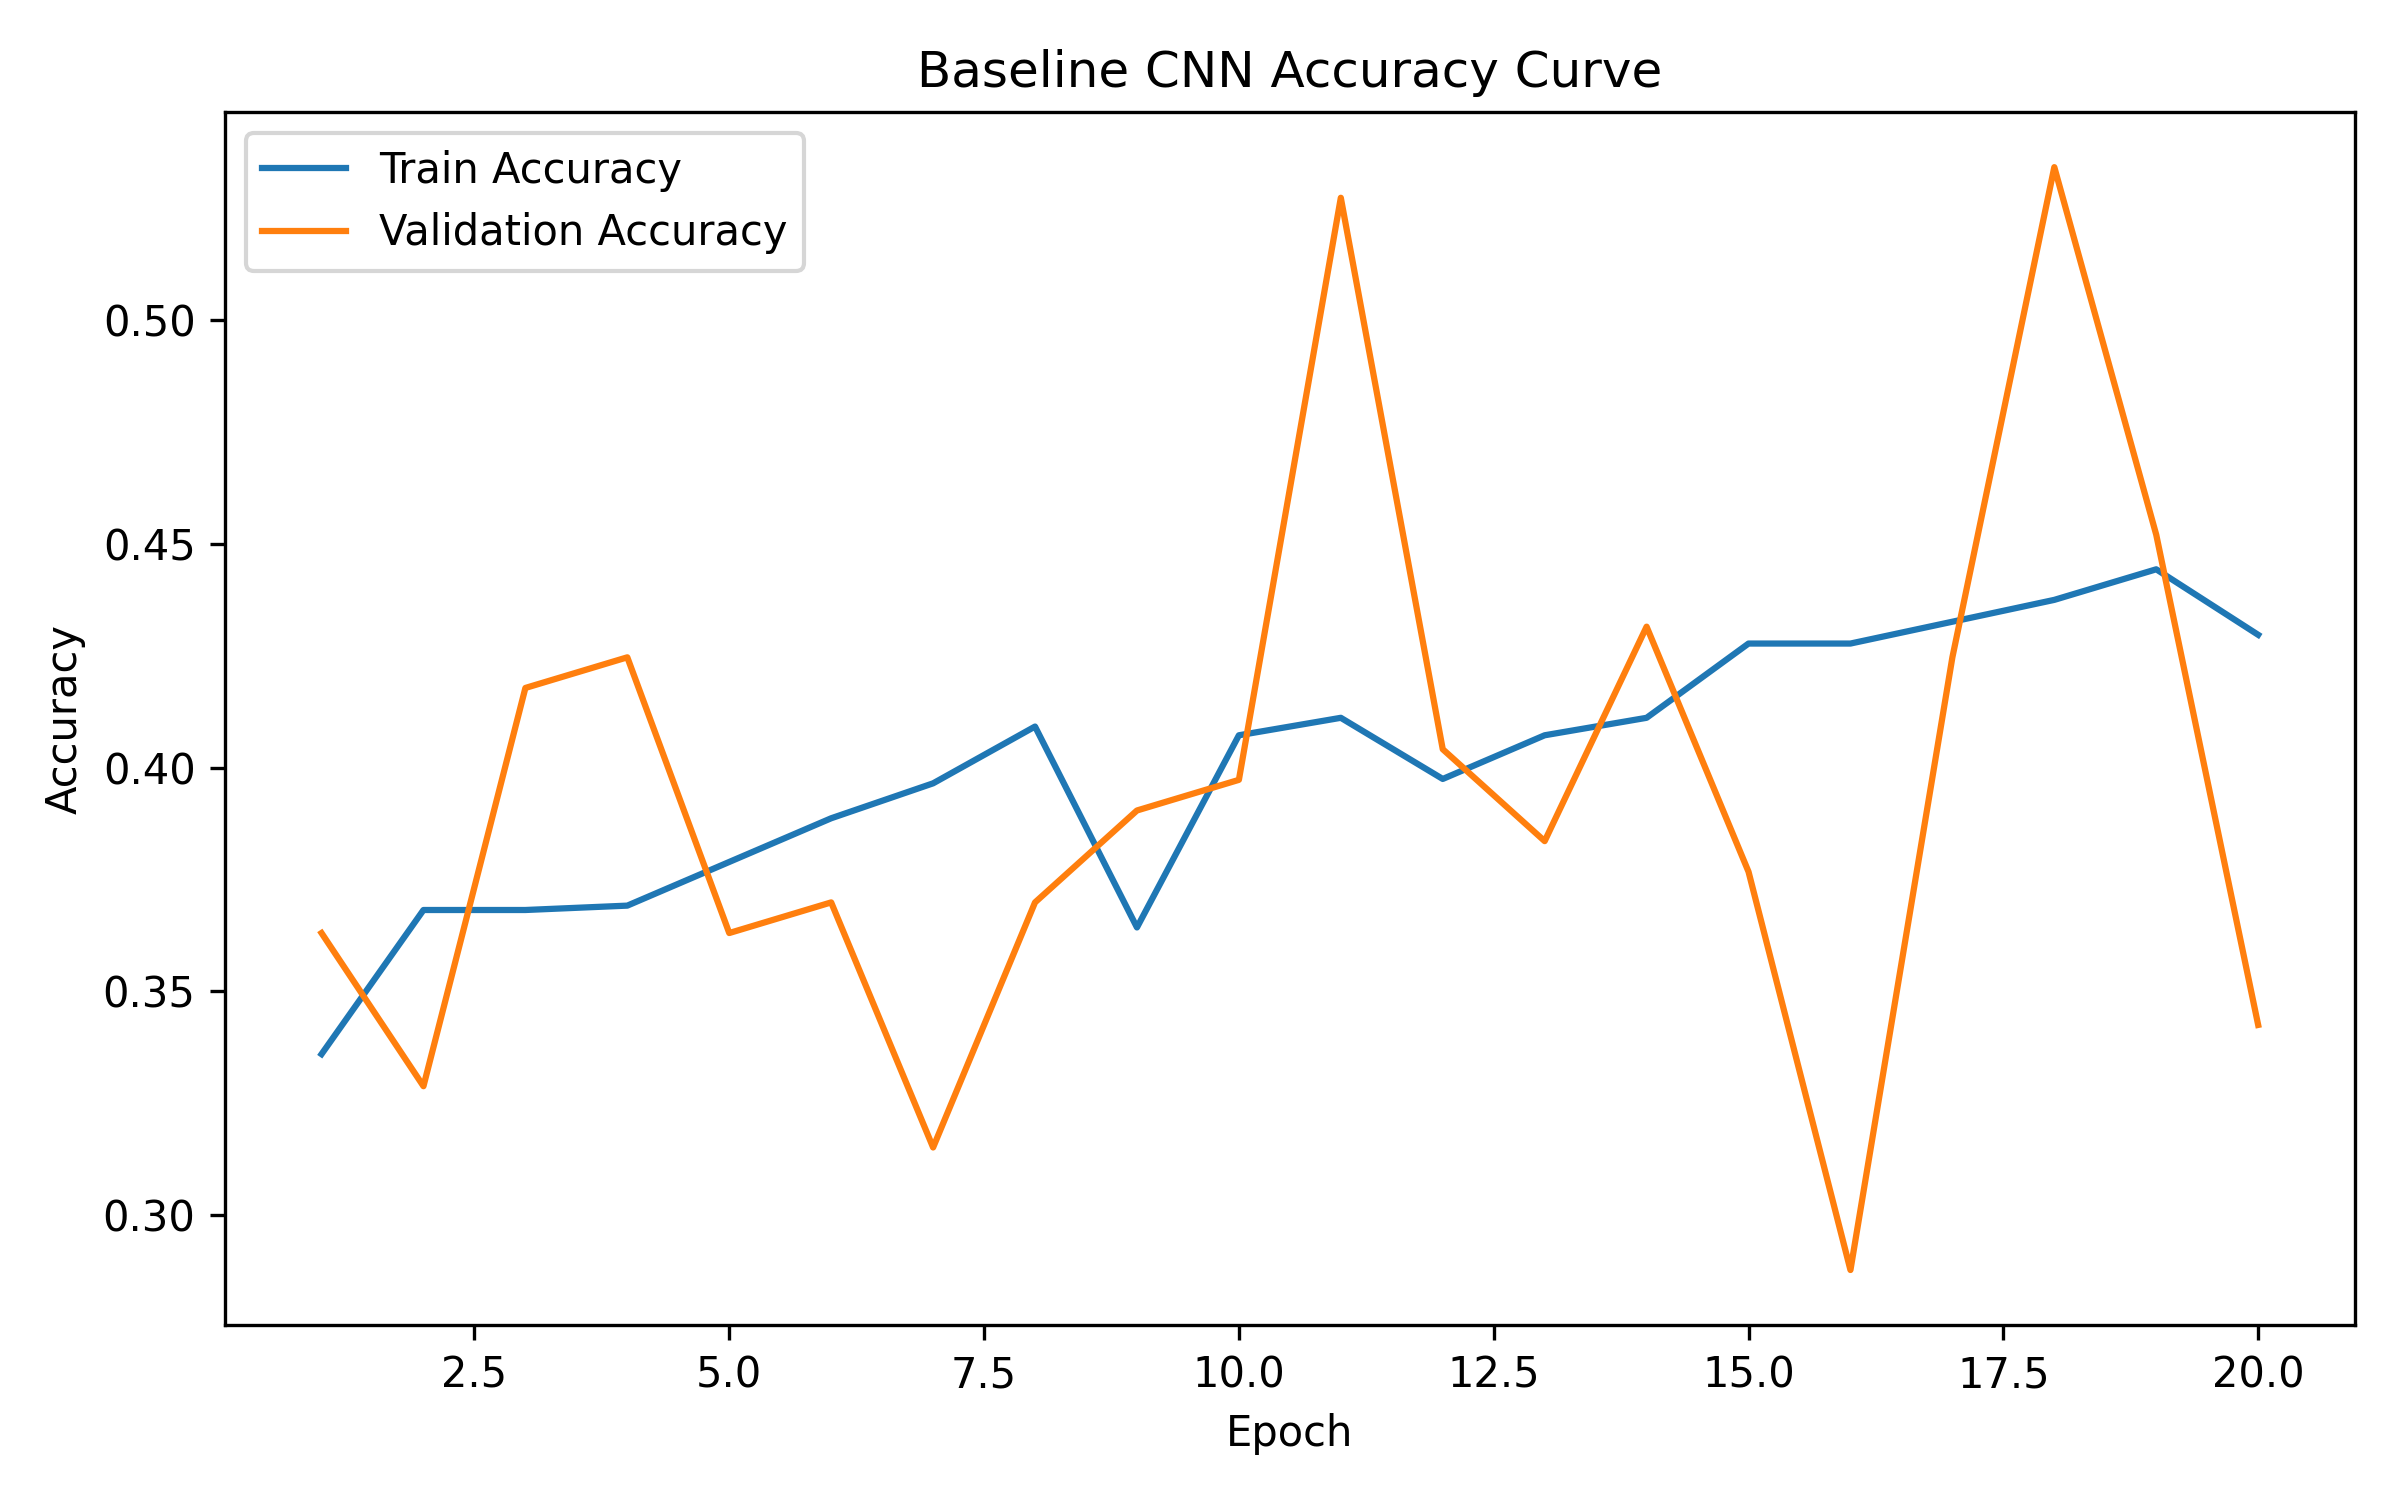

In [22]:
loss_curve_path = FIGURE_DIR / "baseline_loss_curve.png"
acc_curve_path = FIGURE_DIR / "baseline_accuracy_curve.png"

if loss_curve_path.exists():
    display(Markdown("### Loss Curve"))
    display(IPyImage(filename=str(loss_curve_path)))
else:
    display(Markdown(f"Loss curve not found: `{loss_curve_path}`"))

if acc_curve_path.exists():
    display(Markdown("### Accuracy Curve"))
    display(IPyImage(filename=str(acc_curve_path)))
else:
    display(Markdown(f"Accuracy curve not found: `{acc_curve_path}`"))

## 11. Baseline test evaluation

This section reads files generated by:

```bash
python src/evaluate.py
```

Run that script first if these results are missing.

In [23]:
baseline_metrics_path = RESULT_DIR / "baseline_test_metrics.csv"
per_class_metrics_path = RESULT_DIR / "baseline_per_class_metrics.csv"
predictions_path = RESULT_DIR / "baseline_test_predictions.csv"

if baseline_metrics_path.exists():
    display(Markdown("### Overall Baseline Test Metrics"))
    baseline_metrics = pd.read_csv(baseline_metrics_path)
    display(baseline_metrics)
else:
    display(Markdown(
        f"Baseline test metrics not found: `{baseline_metrics_path}`. "
        "Run `python src/evaluate.py` first."
    ))

if per_class_metrics_path.exists():
    display(Markdown("### Per-Class Metrics"))
    per_class_metrics = pd.read_csv(per_class_metrics_path)
    display(per_class_metrics)
else:
    display(Markdown(
        f"Per-class metrics not found: `{per_class_metrics_path}`. "
        "Run `python src/evaluate.py` first."
    ))

if predictions_path.exists():
    display(Markdown("### First 10 Test Predictions"))
    predictions = pd.read_csv(predictions_path)
    display(predictions.head(10))
else:
    display(Markdown(
        f"Prediction file not found: `{predictions_path}`. "
        "Run `python src/evaluate.py` first."
    ))

### Overall Baseline Test Metrics

,model,loss,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,adjacent_error_rate_among_errors,distant_error_rate_among_errors
0,BaselineCNN,CrossEntropyLoss,0.459184,0.373347,0.418762,1.020408,0.505671,159,81,78,0.509434,0.490566


### Per-Class Metrics

,label,class_name,precision,recall,f1_score,support
0,0,Normal,0.513043,0.648352,0.572816,91
1,1,Doubtful,0.516667,0.352273,0.418919,88
2,2,Mild,0.000000,0.000000,0.000000,38
3,3,Moderate,0.413793,0.342857,0.375000,35
4,4,Severe,0.366667,0.785714,0.500000,42


### First 10 Test Predictions

,sample_index,true_label,true_class,pred_label,pred_class,error_distance,prob_0_Normal,prob_1_Doubtful,prob_2_Mild,prob_3_Moderate,prob_4_Severe
0,0,1,Doubtful,1,Doubtful,0,0.298547,0.407675,0.103500,0.046222,0.144055
1,1,4,Severe,4,Severe,0,0.043836,0.274848,0.111132,0.101752,0.468432
2,2,2,Mild,0,Normal,2,0.481957,0.421910,0.044049,0.011829,0.040255
3,3,0,Normal,0,Normal,0,0.423219,0.089532,0.220674,0.231822,0.034751
4,4,0,Normal,1,Doubtful,1,0.322151,0.451237,0.080060,0.029364,0.117189
5,5,0,Normal,0,Normal,0,0.493107,0.398497,0.064415,0.017459,0.026522
6,6,3,Moderate,1,Doubtful,2,0.163114,0.319822,0.166958,0.101377,0.248729
7,7,4,Severe,4,Severe,0,0.046255,0.196076,0.153727,0.243320,0.360622
8,8,1,Doubtful,0,Normal,1,0.355367,0.288888,0.175825,0.079389,0.100532
9,9,1,Doubtful,0,Normal,1,0.425151,0.393858,0.092659,0.034388,0.053944


## 12. Baseline confusion matrix

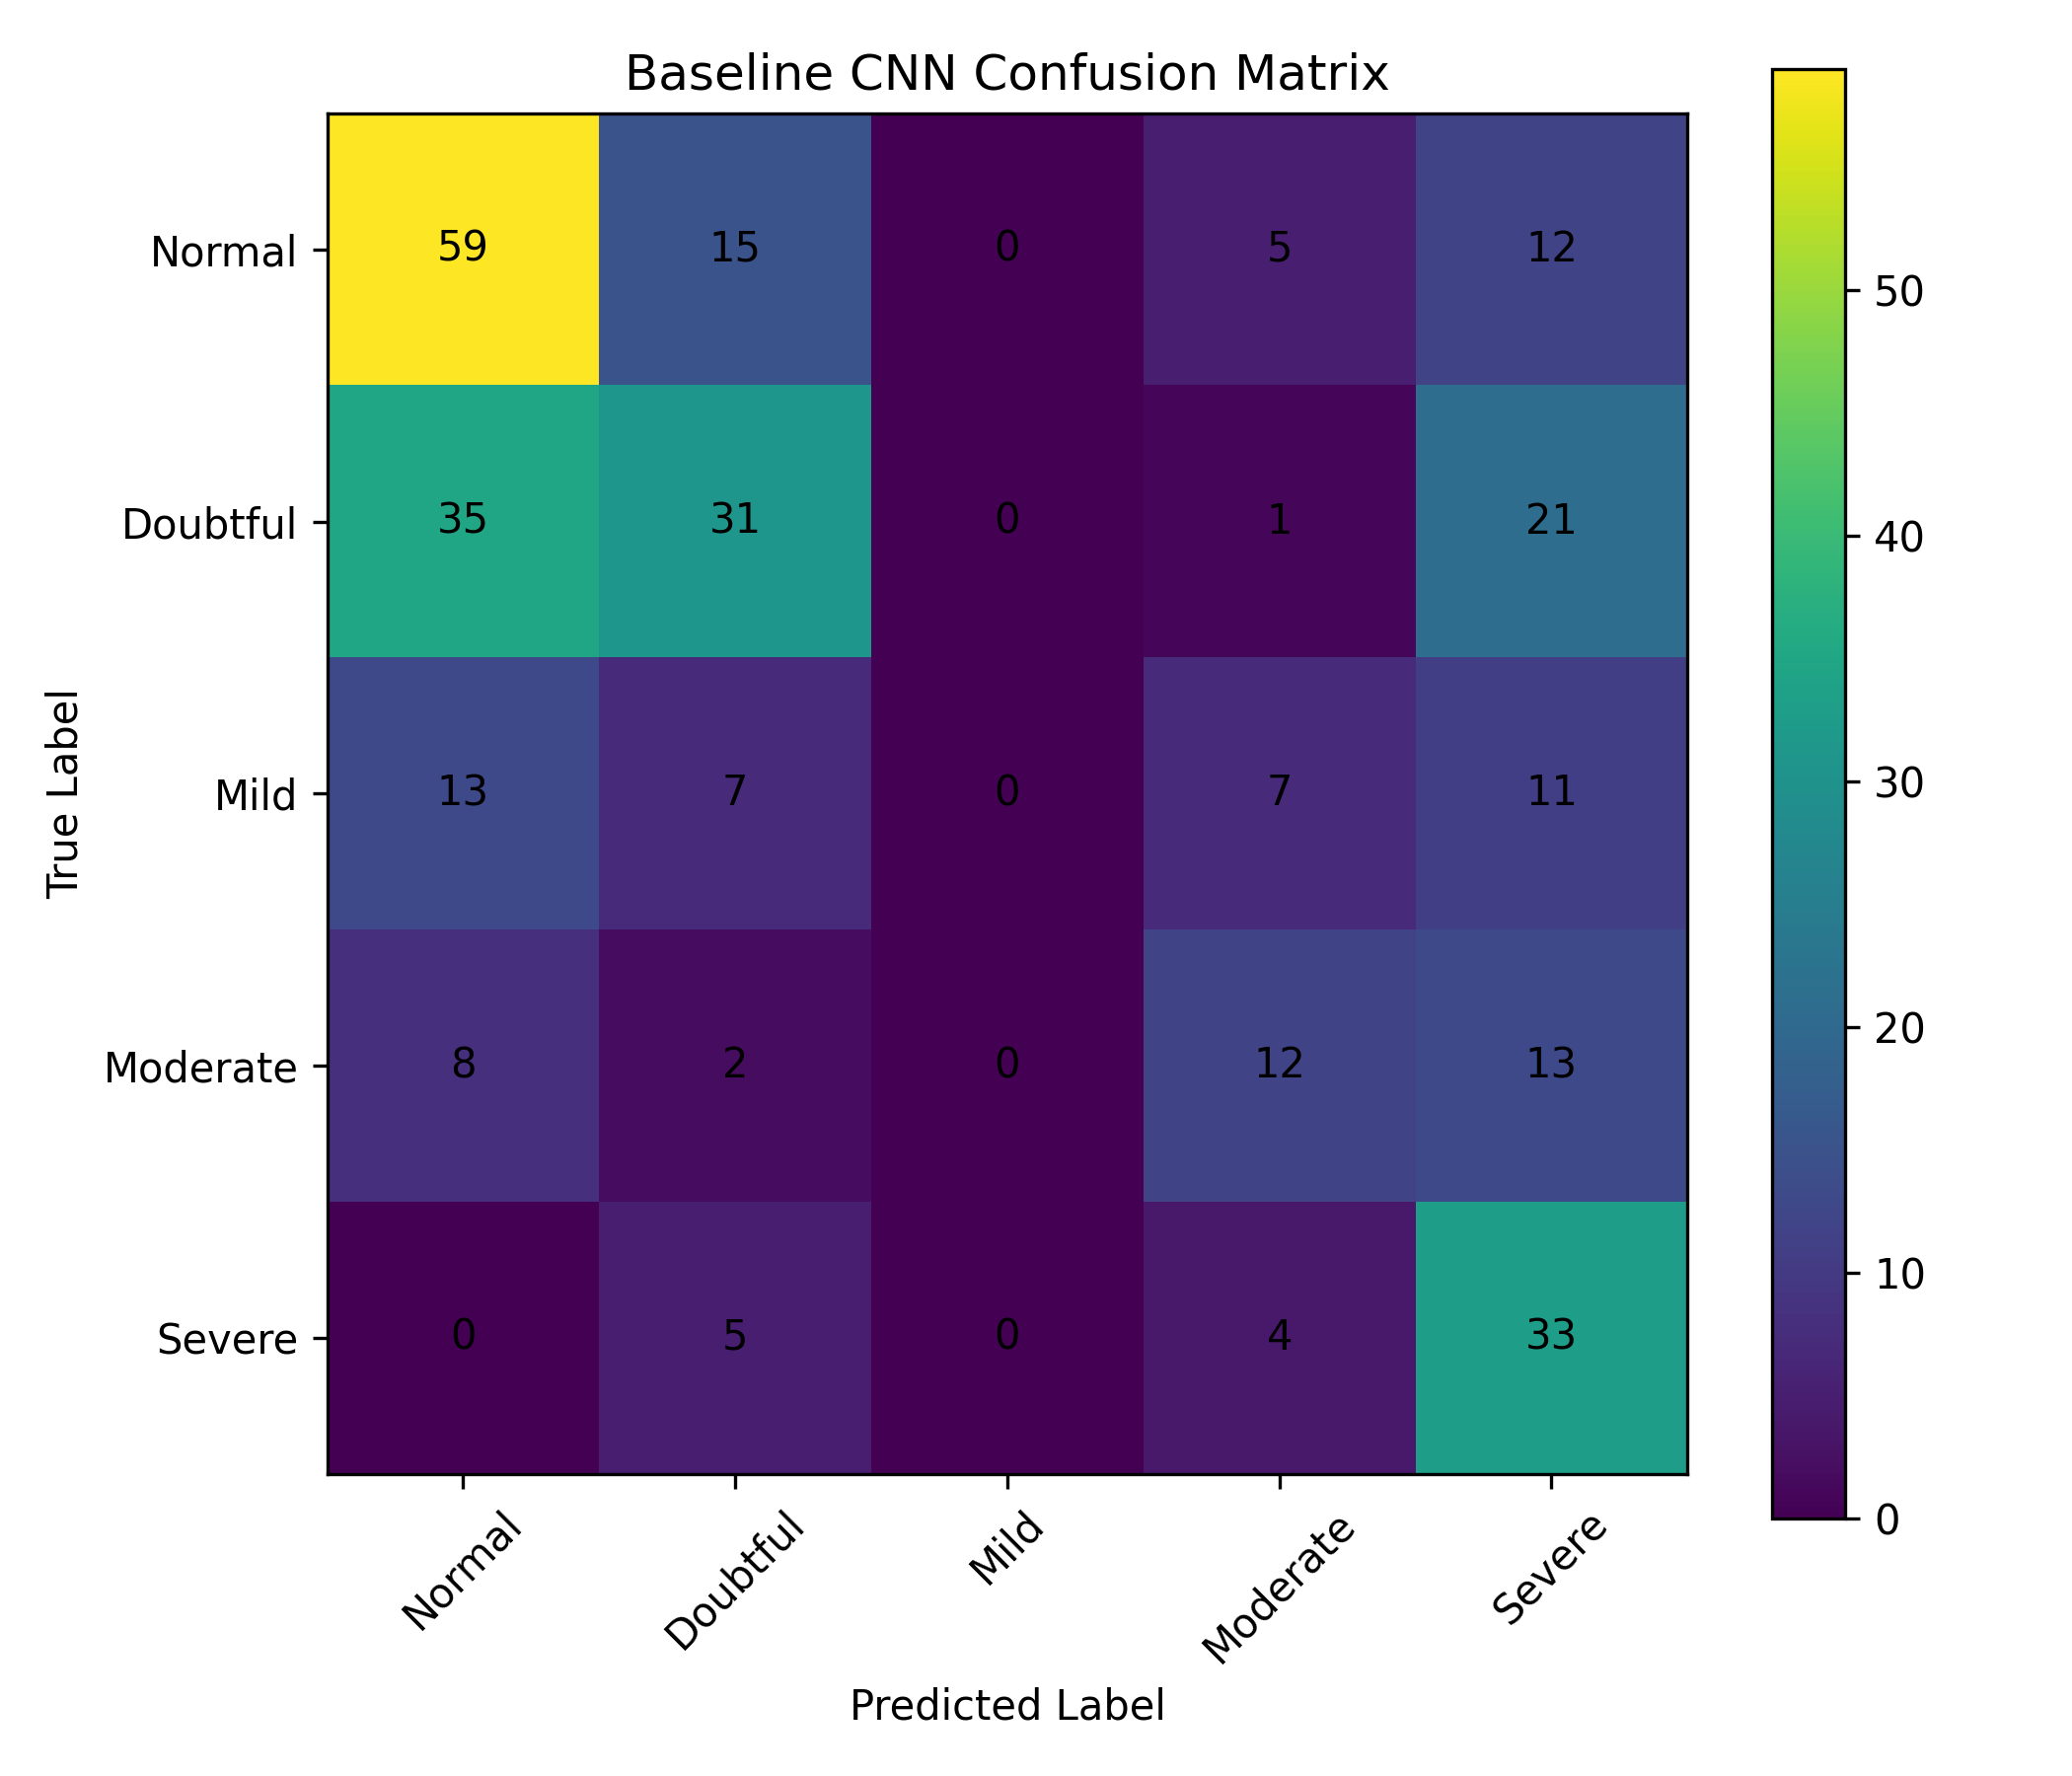

### Confusion Matrix Table

,pred_Normal,pred_Doubtful,pred_Mild,pred_Moderate,pred_Severe
true_Normal,59,15,0,5,12
true_Doubtful,35,31,0,1,21
true_Mild,13,7,0,7,11
true_Moderate,8,2,0,12,13
true_Severe,0,5,0,4,33


In [24]:
confusion_matrix_fig_path = FIGURE_DIR / "baseline_confusion_matrix.png"
confusion_matrix_csv_path = RESULT_DIR / "baseline_confusion_matrix.csv"

if confusion_matrix_fig_path.exists():
    display(IPyImage(filename=str(confusion_matrix_fig_path)))
else:
    display(Markdown(
        f"Confusion matrix figure not found: `{confusion_matrix_fig_path}`. "
        "Run `python src/evaluate.py` first."
    ))

if confusion_matrix_csv_path.exists():
    display(Markdown("### Confusion Matrix Table"))
    cm_df = pd.read_csv(confusion_matrix_csv_path, index_col=0)
    display(cm_df)